In [1]:
# illustrative example of use GEMS 

## Creating a Local Butler for a Selected Set of Visits

> Version: 1.0
> Container Size: Large

> Description: In this notebook, we present illustrative examples of using Vera Rubin’s functions to create a local Butler for a chosen set of visits.

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

!python --version

Release r30.0.11 (RSP Build 3040)
lsst_distrib          gdfb3db0272+232e9e9820 	v30_0_11 current v30_0_11_rc1 o_latest setup
Python 3.13.9


In [3]:
%load_ext autoreload
%autoreload

In [4]:
import numpy as np
import gems
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler

### Loading the butler and show some information

In [5]:
# Initialize Butler
COLLECTION = "LSSTComCam/DP1"
REPOSITORY = "dp1"

butler = Butler(config=REPOSITORY, collections=COLLECTION)
assert butler is not None

In [6]:
import lsst.sphgeom as sphgeom

## Identify visit images around location

In [7]:
# Identify visit images around location
ra_deg, dec_deg = (52.99047151 , -28.39936991) # (53.2, -27.8)
loc_data = ra_deg, dec_deg

bands = ['u', 'i']

visit_name = "visit_image"
print(f"Using -> {visit_name}")

visits_image_selected_list = {}
for band in bands:
    visit_refs = gems.visit_dataset(butler, band, loc_data, type_loc_data='sky_coordinates', detectors=None, timespan=None, visit_ids=None)
    print(f'[INF] Found {len(visit_refs)} visits in band {band}')
    visits_image_selected_list[band] = visit_refs  # Saving the visit data set per band

Using -> visit_image
[INF] Found 24 visits in band u
[INF] Found 96 visits in band i


## Creating the local butler repository and copying the visits

In [8]:
# General CONFIGURATION
LOCAL_REPO = "./local_butler"       # Local butler repo path (relative to this notebook, inside examples/)
REMOTE_REPO = gems.get_butler_location(butler)  # Remote butler repo path
COLLECTION = "LSSTComCam/DP1"

In [9]:
# taking the first four
nbest = 10

visits_u = visits_image_selected_list['u'][:nbest]
visits_i = visits_image_selected_list['i'][:nbest]

In [9]:
def make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits):
    # Make the object/Setup logging directory and logger
    lbutler = gems.LocalButler(local_repo=LOCAL_REPO, remote_repo=REMOTE_REPO, LOGDIR=LOCAL_REPO+"/logs")

    # Creating an empty butler
    lbutler.make_repo()

    # Register instruments (collect unique instrument names from DatasetRefs)
    lbutler.reg_instruments(visits_u, remote_collection=COLLECTION)

    # Registering SkyMap DatasetType and copying skyMap dataset(s) (preserving UUIDs)
    lbutler.reg_transfer_skyMap(remote_collection=COLLECTION)

    # transfer some datasets associated to "visit_image"
    for visits in data_visits:
        lbutler.discover_transfer_datasets(visits, remote_collection=COLLECTION)

    # Finally, create a chained collection
    lbutler.chained(chain_name="local_main_chain")

    return True

In [9]:
# Making the local butler
data_visits = [visits_u, visits_i]

make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits)

2026-09-04 19:17:04 [INFO] Created LOGDIR at ./local_butler./local_butler/logs


2026-09-04 19:17:04 [INFO] Starting pipeline for local repo: ./local_butler


2026-09-04 19:17:04 [INFO] Creating Butler repo at ./local_butler


2026-09-04 19:17:05 [INFO] Registering instruments: ['LSSTComCam']


2026-09-04 19:17:05 [INFO] Detected instruments to register: ['LSSTComCam']


...

2026-09-04 19:21:55 [INFO] Making a chained collection


2026-09-04 19:21:55 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-09-04 19:21:56 [INFO] Registered CHAINED collection: local_main_chain


2026-09-04 19:21:56 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


True

## Visualizing some local butler's information

In [10]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected                                             RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/

In [11]:
# Dataset types
print("List of avalibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of avalibles datasetType:
     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [12]:
# Skymap collection
print("List of avalibles Skymaps:")
!butler query-datasets $LOCAL_REPO skyMap --collections skymaps

List of avalibles Skymaps:

 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [13]:
# identifying the RUN name of visit_summary
!butler query-datasets $LOCAL_REPO visit_summary \
  --collections local_main_chain \
  --limit 60


     type                                run                                             id                  instrument     visit     band day_obs  physical_filter
------------- --------------------------------------------------------- ------------------------------------ ---------- ------------- ---- -------- ---------------
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z ae9428b6-f1dd-43a7-bb82-d7c93b5d7964 LSSTComCam 2024110800248    i 20241108            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 65a8f56e-6bf3-42de-86ee-f7d58ac7d7cd LSSTComCam 2024110800253    i 20241108            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z cbb52321-1a09-4dc7-9a27-1e48a80ed21b LSSTComCam 2024110800260    i 20241108            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z c23dfc1a-0764-4af8-8cfe-1b3d7498fc4d LSSTComCam 2024110800261    i 20241108            i_06
visit_summary L

## Stamp Injection

In this example, we perform the injection and simultaneously store the new (stamp-injected) visit_image in the butler. For an example where the new (stamp-injected) visit_image is already provided, see the `injection_example notebook`.

In [32]:
# First: we need to create a new RUN and a CHAIN with only the skymap and visit_summary, because we preserved the dataId of the visits.
# IMPORTANT: if the RUN exists, we jump this step

# Adding the new RUN/CHAIN
members = ['skymaps',
           'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z'  # visit_summary
          ]


run_name = "run_with_injection_4"
chain_name = "local_with_injection_4"
gems.ensure_chained_collection(local_repo=LOCAL_REPO, 
                             run_name=run_name,
                             chain_name=chain_name,
                             members=members)

True

In [33]:
# Notice as appear a new Collections

print("List of avalibles colections:")
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
direct_injected                                             RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
local_with_injection                                        CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/

In [34]:
def random_position(REPO, collection, skymap_name, loc, num):
    """
    Generate `num` random RA/Dec positions inside the patch corresponding
    to the sky location `loc = (ra_deg, dec_deg)`, including loc.
    """
    import lsst.geom as geom

    ra_deg, dec_deg = loc
    if num == 1: return [ra_deg], [dec_deg]
    point_sky = geom.SpherePoint(ra_deg, dec_deg, geom.degrees)
    
    butler = Butler(REPO, collections=collection)
    sky_map = butler.get("skyMap", skymap=skymap_name)

    tract_info = sky_map.findTract(point_sky)
    patch_info = tract_info.findPatch(point_sky)

    bbox = patch_info.getOuterBBox()
    wcs = tract_info.getWcs()
    
    xmin, ymin = bbox.getMin()
    xmax, ymax = bbox.getMax()

    x = np.random.uniform(xmin, xmax, num - 1)
    y = np.random.uniform(ymin, ymax, num - 1)

    ra_list, dec_list = [ra_deg], [dec_deg]
    for xi, yi in zip(x, y):
        sky = wcs.pixelToSky(geom.Point2D(xi, yi))
        ra_list.append(sky.getRa().asDegrees())
        dec_list.append(sky.getDec().asDegrees())

    return ra_list, dec_list

In [35]:
# Second: we make the injection of the stamp/s and put the results in our butler

# Defining the sky coordinates and the selected band
ra_deg, dec_deg = (52.99047151 , -28.39936991)
loc_data = (ra_deg, dec_deg)
bands = 'ui'
visits = {'u': visits_u, 'i': visits_i}

# Opening the FITS file
stamp_paths = ['stamp/test.fits']
               #'stamp/test.fits',
               #'stamp/test.fits'
              #]

# Defining the properties of the stamp
mags = [14.8]#, 14.8, 14.8]  # Magnitude used to inject the stamp

# Sky position of the injection
ra_list, dec_list = random_position(LOCAL_REPO,
                                    collection='local_main_chain',
                                    skymap_name="lsst_cells_v1",
                                    loc=loc_data, num=len(stamp_paths))

In [36]:
lbutler = Butler(LOCAL_REPO, collections='local_main_chain') 
refs_inj_visit = lbutler.query_datasets("visit_image")
visit_img = lbutler.get('visit_image', dataId=refs_inj_visit[0].dataId)
ref_wcs = visit_img.getWcs()

In [37]:
# Injecting
injected_exposure_data = []
for band in bands:
    injected_exposure = gems.main_inject_stamp(
        REPO=REMOTE_REPO, # alternatively we can use LOCAL_REPO,
        collections="LSSTComCam/DP1",  # alternatively we can use "local_main_chain",
        visit_ids=[visit.dataId["visit"] for visit in visits[band]],  # use in case of a remote repo is choose
        loc=loc_data,
        band=band,
        stamp_paths=stamp_paths,
        mags=mags,
        ra_list=ra_list,
        dec_list=dec_list,
        REPO_SAVE=LOCAL_REPO,  # important to save directly on the butler 
        collection_save=chain_name,  # important to save directly on the butler 
        run_name_save=run_name,  # important to save directly on the butler 
        update_wcs=False,
        info_save_path=None,
        rot_name_save="/home/jhuda/WORK/gems/examples/test/stamp_rotated",
        remove_rotated_stamps=True,
        info=True,
        ref_wcs=ref_wcs,
        min_sep=None)

    injected_exposure_data.append(injected_exposure)

[INFO] Loading the butler...
[INFO] Injection on sky coordinates: RA=52.99047151, Dec=-28.39936991
[INFO] Found 10 visits for band=u
END: Collect visit exposures and getWcs info
Execution time: 23.737 seconds
[INFO] Using 10 visits after sorting and selection.
[INFO] Computed 10 rotation angles.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.0_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.0_stamp_0.fits'}]


[SAVE] visit 2024113000174 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_153.1531391943168_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_153.1531391943168_stamp_0.fits'}]


[SAVE] visit 2024113000172 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_153.8934498897909_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_153.8934498897909_stamp_0.fits'}]


[SAVE] visit 2024113000173 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_359.48094255364185_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_359.48094255364185_stamp_0.fits'}]


[SAVE] visit 2024110900203 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_359.7734746110894_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_359.7734746110894_stamp_0.fits'}]


...

[SAVE] visit 2024110800264 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.0012564327536772964_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.0012564327536772964_stamp_0.fits'}]


[SAVE] visit 2024110800261 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.009071358555117716_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.009071358555117716_stamp_0.fits'}]


[SAVE] visit 2024110800297 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.005404047419107374_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.005404047419107374_stamp_0.fits'}]


[SAVE] visit 2024110800284 stored successfully.
['/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.006304104838539048_stamp_0.fits']
[{'ra': 52.99047151, 'dec': -28.39936991, 'mag': 14.8, 'stamp': '/home/jhuda/WORK/gems/examples/test/stamp_rotated_angle_0.006304104838539048_stamp_0.fits'}]


[SAVE] visit 2024110800248 stored successfully.
[INFO] Injection complete.


In [38]:
# Validating
!butler query-datasets $LOCAL_REPO visit_image \
  --collections $chain_name \
  --limit 60


    type            run                           id                  instrument detector     visit     band day_obs  physical_filter
----------- -------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image run_with_injection_4 01a07cd8-06be-70d6-bab0-040dab729a21 LSSTComCam        3 2024110800248    i 20241108            i_06
visit_image run_with_injection_4 01a07cd7-3ec5-77f1-b0b9-00c7b25a0d6c LSSTComCam        3 2024110800253    i 20241108            i_06
visit_image run_with_injection_4 01a07cd7-9a98-7fab-8120-fe1e83595d58 LSSTComCam        3 2024110800260    i 20241108            i_06
visit_image run_with_injection_4 01a07cd7-c666-7308-81d5-f78c79091e79 LSSTComCam        0 2024110800261    i 20241108            i_06
visit_image run_with_injection_4 01a07cd7-b080-7bdd-abd2-45d8a9845e5f LSSTComCam        3 2024110800264    i 20241108            i_06
visit_image run_with_injection_4 01a07cd7-56c5-7a58-ab4f-b1d3

In [39]:
chain_name

'local_with_injection_4'

## Plot the result

In [40]:
lbutler = Butler(LOCAL_REPO, collections='local_main_chain') 

inj_lbutler = Butler(LOCAL_REPO, collections='local_with_injection_4') 

In [41]:
# extracting visits
refs_inj_visit = inj_lbutler.query_datasets("visit_image")

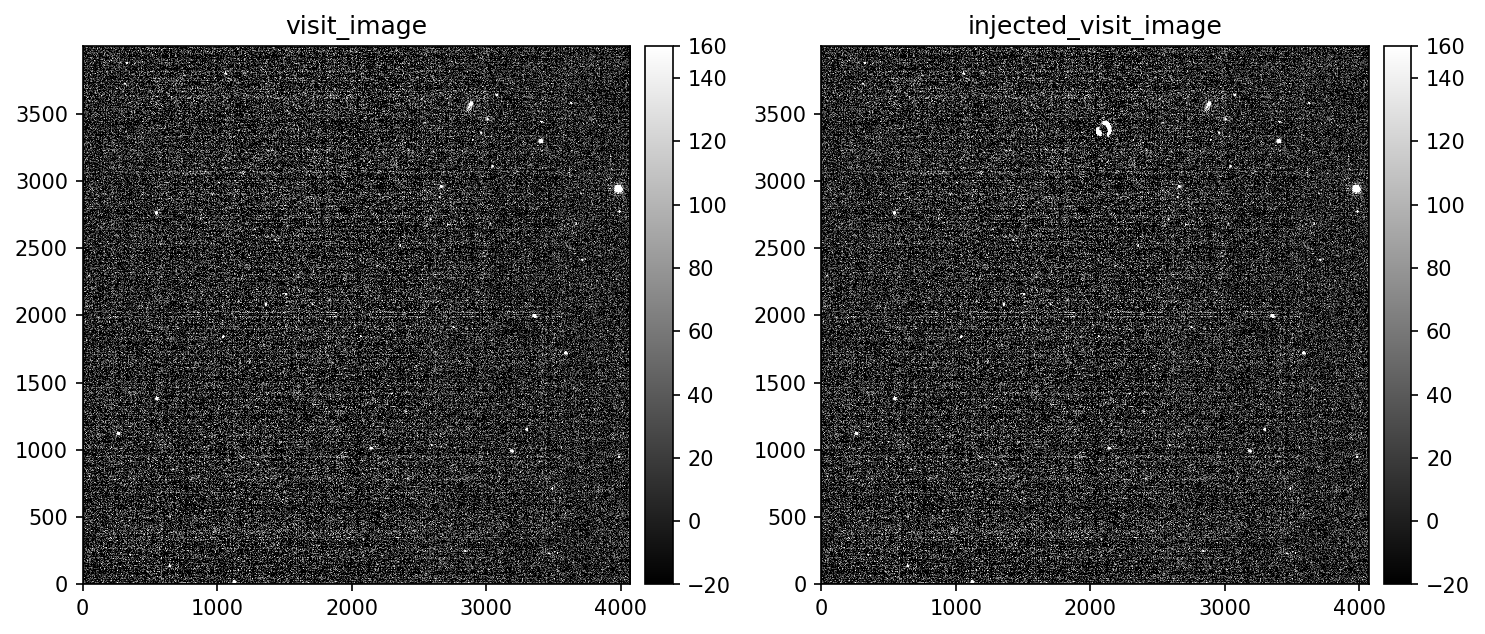

In [42]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")

num = 3
visit_img = lbutler.get('visit_image', dataId=refs_inj_visit[num].dataId)
plot_injected_img = inj_lbutler.get('visit_image', dataId=refs_inj_visit[num].dataId)

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(visit_img.image)
plt.title('visit_image')

plt.sca(ax[1])
display1 = afwDisplay.Display(frame=fig)
# display1.scale('linear', 'zscale')
display1.scale('linear', min=-20, max=150)
display1.mtv(plot_injected_img.image)
# To zoom on the PGC 038749 stamp:
# display1.mtv(plot_injected_img.image[1700:2200, 1950:2450])
plt.title('injected_visit_image')

plt.tight_layout()
plt.show()

### Making a deep coadd

In [43]:
import pandas as pd

In [44]:
refs = inj_lbutler.query_datasets("visit_image")

visits_selected = {'visit_id': [], 'band': []}
for ref in refs:
    visits_selected['visit_id'].append(ref.dataId.get('visit'))
    visits_selected['band'].append(ref.dataId.get('band'))

pd_visits_selected = pd.DataFrame(visits_selected)

In [88]:
pd_visits_selected

,visit_id,band
0,2024110800261,i
1,2024110800284,i
2,2024110900203,u
3,2024110900212,u
4,2024110800248,i
5,2024110800253,i
6,2024110800260,i
7,2024110800264,i
8,2024110800265,i
9,2024110800297,i


In [46]:
# Identify visit images around location
loc_data = ra_deg, dec_deg

In [47]:
gems.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection=chain_name,
                          my_collection_name='custom_coadd',
                          type_loc_data='sky_coordinates',
                          SAVE_FITS=False,
                          out=False)

[INFO] Metadata saved: ./local_butler/custom_coadd_info.txt


In [48]:
# some checks
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd                                                CHAINED
  custom_coadd/20260907T171741Z                             RUN    
  custom_coadd/inputs                                       TAGGED 
custom_coadd/20260907T171741Z                               RUN    
custom_coadd/inputs                                         TAGGED 
direct_injected                                             RUN    
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335              

In [49]:
!butler query-dataset-types $LOCAL_REPO --collections custom_coadd

             name             
------------------------------
assembleDeepCoadd_config      
assembleDeepCoadd_log         
assembleDeepCoadd_metadata    
compare_warp_artifact_mask    
deep_coadd_input_map          
deep_coadd_n_image            
deep_coadd_predetection       
deep_coadd_visit_selection    
direct_warp                   
direct_warp_masked_fraction   
makeDirectWarp_config         
makeDirectWarp_log            
makeDirectWarp_metadata       
makePsfMatchedWarp_config     
makePsfMatchedWarp_log        
makePsfMatchedWarp_metadata   
packages                      
psf_matched_warp              
selectDeepCoaddVisits_config  
selectDeepCoaddVisits_log     
selectDeepCoaddVisits_metadata
skyMap                        
visit_image                   
visit_summary                 


In [50]:
!butler query-datasets $LOCAL_REPO deep_coadd_visit_selection \
  --collections custom_coadd \
  --limit 5


           type                         run                               id                  band instrument     skymap    tract patch
-------------------------- ----------------------------- ------------------------------------ ---- ---------- ------------- ----- -----
deep_coadd_visit_selection custom_coadd/20260907T171741Z 01a07ce0-305a-7a25-83bd-cc35f8915508    i LSSTComCam lsst_cells_v1  4848    80
deep_coadd_visit_selection custom_coadd/20260907T171741Z 01a07ce0-305a-7ba1-afd6-cc1b45baf109    u LSSTComCam lsst_cells_v1  4848    80



### Comparing with the full deep_coadd

In [51]:
import os
import json

In [52]:
local_repo_path = LOCAL_REPO #os.path.join(os.getenv("HOME"), LOCAL_REPO) 
info_txt_path = os.path.join(local_repo_path, "custom_coadd_info.txt")

with open(info_txt_path, "r") as f:
        info = json.load(f)

info

{'repo_path': './local_butler',
 'collection': 'custom_coadd/20260907T171741Z',
 'coadd_type': 'deep_coadd_predetection',
 'tract': 4848,
 'patch': '80',
 'bands': ['i', 'u'],
 'instrument': 'LSSTComCam',
 'skymap': 'lsst_cells_v1'}

In [57]:
lbutler = Butler(LOCAL_REPO, collections="local_main_chain")

inj_coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd') 

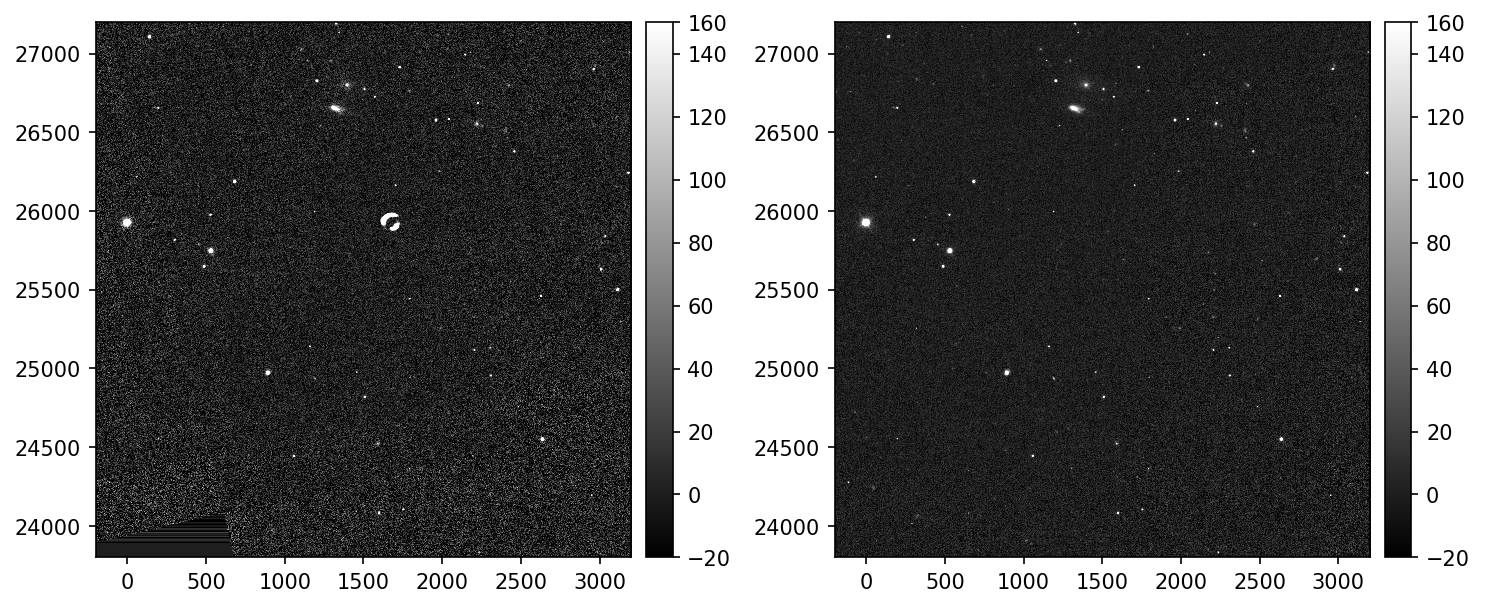

In [60]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")


coadd = lbutler.get('deep_coadd', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 4848, 'patch': 80})
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 4848, 'patch': 80})

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(inj_coadd.image)


plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd.image)

plt.tight_layout()

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/jhuda/WORK/gems/py/gems/utils/plot/exposure_plot.py:221: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


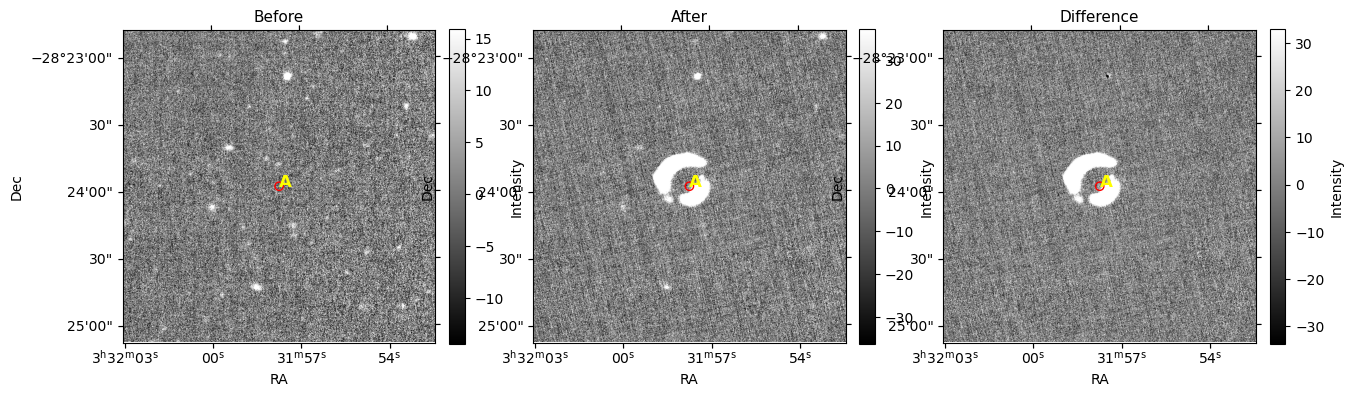

In [61]:
# Simple comparison (subtraction of both)
points = [loc_data]
before = coadd
after = inj_coadd

# necessary because the corner no is (0, 0)
bbox = after.getBBox()
xmin = bbox.getMinX()
xmax = bbox.getMaxX()
ymin = bbox.getMinY()
ymax = bbox.getMaxY()

gems.injection_steps(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=70,  # arcsec  10
                   grid=False, percentiles=[5, 95],
                   extent=[xmin, xmax, ymin, ymax])

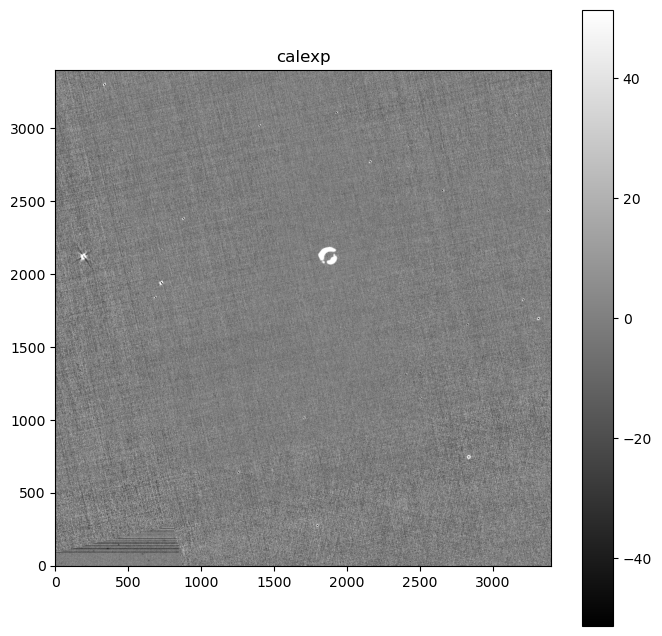

In [62]:
diff = inj_coadd.clone()
diff.image.array[:] = inj_coadd.image.array - coadd.image.array

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()

### Testing the coadd with the rotate/inject visits

In [63]:
inj_lbutler = Butler(LOCAL_REPO, collections='local_with_injection') 
inj_coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd') 

In [64]:
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection',
                                  dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 4848, 'patch': 80})

In [65]:
from lsst.afw.image import ExposureF, MaskedImageF
from lsst.afw.math import warpExposure, WarpingControl

# Get reference geometry and WCS
ref_exp = inj_coadd.clone()

dims = ref_exp.getMaskedImage().getDimensions()
ref_wcs = ref_exp.getWcs()
ref_bbox = ref_exp.getBBox()

In [66]:
# refs_inj_visit

## Making a coadd with the same visit number, but without the injected stamp

In [68]:
gems.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection="local_main_chain",  # important change the collection
                          my_collection_name='custom_coadd_without_stamp',
                          type_loc_data='sky_coordinates',
                          SAVE_FITS=False,
                          out=False,
                          meta_data_name ="custom_coadd_info_without_stamp")

[INFO] Metadata saved: ./local_butler/custom_coadd_info_without_stamp.txt


In [69]:
# some checks
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd                                                CHAINED
  custom_coadd/20260907T171741Z                             RUN    
  custom_coadd/inputs                                       TAGGED 
custom_coadd/20260907T171741Z                               RUN    
custom_coadd/inputs                                         TAGGED 
custom_coadd_without_stamp                                  CHAINED
  custom_coadd_without_stamp/20260907T175017Z               RUN    
  custom_coadd_without_stamp/inputs                         TAGGED 
custom_coadd_without_stamp/20260907T174420Z                 RUN    
custom_coadd_without_stamp/20260907T175017Z     

In [70]:
!butler query-dataset-types $LOCAL_REPO --collections custom_coadd_without_stamp

             name             
------------------------------
assembleDeepCoadd_config      
assembleDeepCoadd_log         
assembleDeepCoadd_metadata    
compare_warp_artifact_mask    
deep_coadd_input_map          
deep_coadd_n_image            
deep_coadd_predetection       
deep_coadd_visit_selection    
direct_warp                   
direct_warp_masked_fraction   
makeDirectWarp_config         
makeDirectWarp_log            
makeDirectWarp_metadata       
makePsfMatchedWarp_config     
makePsfMatchedWarp_log        
makePsfMatchedWarp_metadata   
packages                      
psf_matched_warp              
selectDeepCoaddVisits_config  
selectDeepCoaddVisits_log     
selectDeepCoaddVisits_metadata
skyMap                        
visit_image                   
visit_summary                 


In [71]:
inj_coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd')
coadd_lbutler = Butler(LOCAL_REPO, collections='custom_coadd_without_stamp') 

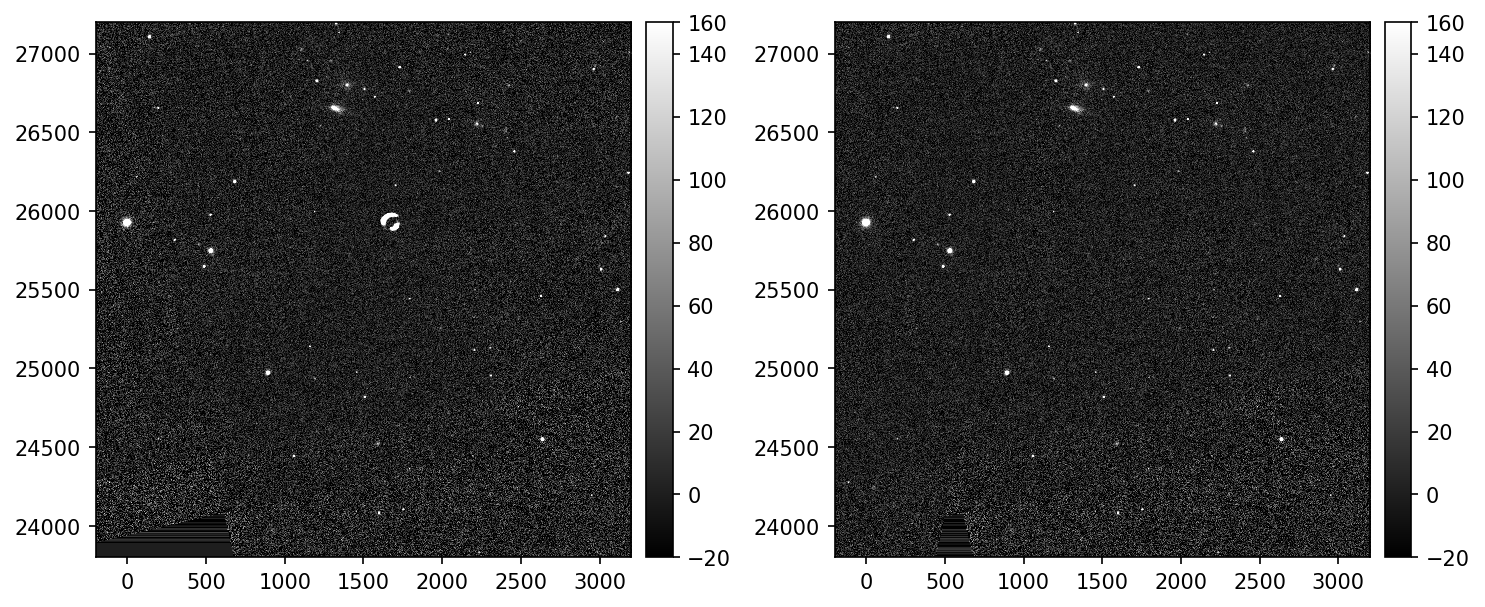

In [89]:
afwDisplay.setDefaultBackend("matplotlib")


custom_coadd = coadd_lbutler.get('deep_coadd_predetection', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 4848, 'patch': 80})
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection', dataId={'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 4848, 'patch': 80})

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(inj_coadd.image)


plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(custom_coadd.image)

plt.tight_layout()

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/jhuda/WORK/gems/py/gems/utils/plot/exposure_plot.py:221: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


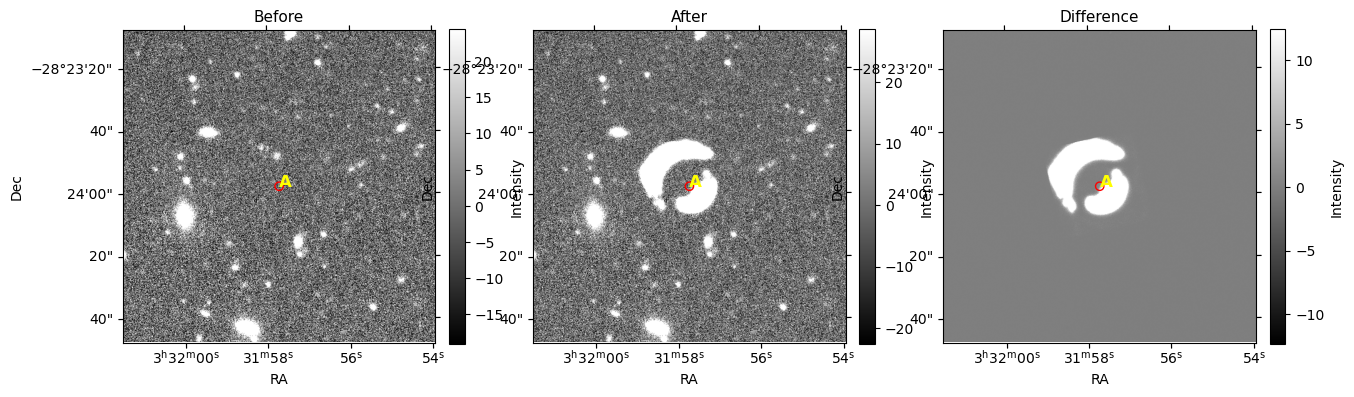

In [83]:
# Simple comparison (subtraction of both)
points = [loc_data]
before = custom_coadd
after = inj_coadd

# necessary because the corner no is (0, 0)
bbox = after.getBBox()
xmin = bbox.getMinX()
xmax = bbox.getMaxX()
ymin = bbox.getMinY()
ymax = bbox.getMaxY()

gems.injection_steps(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=50,  # arcsec  10
                   grid=False, percentiles=[5, 95],
                   extent=[xmin, xmax, ymin, ymax])

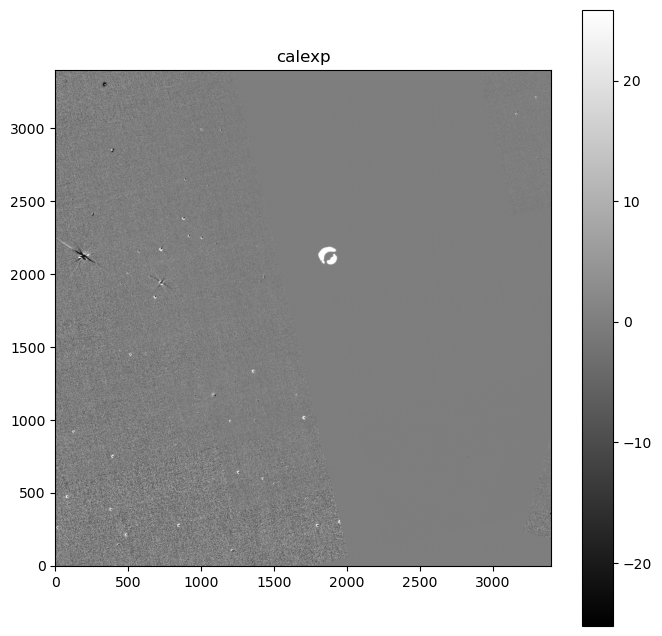

In [84]:
diff = inj_coadd.clone()
diff.image.array[:] = inj_coadd.image.array - custom_coadd.image.array

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()

In [90]:
info_cc = custom_coadd.getInfo()
info_ic = inj_coadd.getInfo()
inputs_cc = info_cc.getCoaddInputs()
inputs_ic = info_ic.getCoaddInputs()

In [91]:
inputs_cc.visits.asAstropy()

id,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,goodpix,weight,filter
,pix,pix,pix,pix,,,
int64,int32,int32,int32,int32,int32,float64,str32
2024110900197,-456,23544,3455,27455,11776233,0.0006353900285338385,u_02
2024110900199,-456,23544,3455,27455,10313604,0.0005373005370182385,u_02
2024110900203,-456,23544,3455,27455,10423476,0.0006202531545291382,u_02
2024110900204,-456,23544,3455,27455,9342557,0.0006254803506553559,u_02
2024110900205,-456,23544,3455,27455,14065372,0.0006226570094037937,u_02
2024110900217,-456,23544,3455,27455,6530252,0.0005808123780175377,u_02
2024113000174,-456,23544,3455,27455,13763588,0.0007945450921199212,u_02


In [92]:
inputs_ic.visits.asAstropy()

id,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,goodpix,weight,filter
,pix,pix,pix,pix,,,
int64,int32,int32,int32,int32,int32,float64,str32
2024110900197,-456,23544,3455,27455,8575512,0.0006431183985769624,u_02
2024110900199,-456,23544,3455,27455,6786443,0.0004997850489385628,u_02
2024110900203,-456,23544,3455,27455,8538579,0.000615452270319449,u_02
2024110900204,-456,23544,3455,27455,9044405,0.0006255671769752028,u_02
2024110900205,-456,23544,3455,27455,12009740,0.0006351055120222393,u_02
2024110900217,-456,23544,3455,27455,3596163,0.0006606786428546769,u_02
2024113000174,-456,23544,3455,27455,7600637,0.0006227516997712626,u_02
